In [11]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

load_dotenv()

True

In [12]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

In [13]:
class UpdatedEvaluate(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description = "Evaluation of tweet - 'approved' or 'needs_improvement'")
    feedback: str = Field(..., description = "Feedback of the tweet generated")

In [14]:
generate_llm = ChatOllama(model = "llama3.2:latest")

evaluate_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")
evaluate_llm = evaluate_llm.with_structured_output(UpdatedEvaluate)

optimize_llm = ChatGroq(model = "openai/gpt-oss-120b")

In [15]:
def generate(state: TweetState):
    prompt = f""""
            You are a funny and clever Twitter/X influencer.
            Write a short, original, and hilarious tweet on the topic: {state['topic']}.

            Rules:
            - Do not use question answer format
            - Max 280 Characters
            - Use observational humor, irony, sarcasm, or cultural references
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english.
    """

    response = generate_llm.invoke(prompt)
    return {"tweet": response.content}

In [16]:
def evaluate(state: TweetState):
    prompt = f"""
            You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format.
            Evaluate the tweet: {state['tweet']}

            Use the criteria below to evaluate the tweet.

            1. Originality - Is this fresh, or have you seen it a hundred times before?
            2. Humor - Did it genuinely make you smile, laugh or chuckle?
            3. Punchiness - Is it short, sharp, and scroll-stopping?
            4. Virality-Potential - Would people retweet or share it?
            5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke 
            - Don't end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces")

            ### Respond only in structured format:
            - evaluation: "approved" or "needs_improvement"
            - feedback: One paragraph explaining the strengths and weaknesses
    """

    response = evaluate_llm.invoke(prompt)

    return {"evaluation": response.evaluation, "feedback": response.feedback}

In [ ]:
def optimize(state: TweetState):
    prompt = f"""
            You punch up tweets for virality and humor based on the feedback given.
            Improve the tweet based on this feedback:
            {state['feedback']}

            Topic: {state['topic']}
            Original tweet: {state['tweet']}

            Re-write it as a short, viral worthy tweet. Avoid Q&A style and stay under 280 characters.
    """

    response = optimize_llm.invoke(prompt).content
    iteration = state["iteration"] + 1
    
    return {"tweet": response, "iteration": iteration}

def decision_making(state: TweetState):
    if (state["iteration"] >= state["max_iteration"]) or (state["evaluation"] == "approved"):
        return "approved"
    return "needs_improvement"

In [18]:
graph = StateGraph(TweetState)

graph.add_node("Generate", generate)
graph.add_node("Evaluate", evaluate)
graph.add_node("Optimize", optimize)

graph.add_edge(START, "Generate")
graph.add_edge("Generate", "Evaluate")
graph.add_conditional_edges(
    "Evaluate",
    decision_making,
    {
        "approved": END,
        "needs_improvement": "Optimize"
    }
)
graph.add_edge("Optimize", "Evaluate")

workflow = graph.compile()

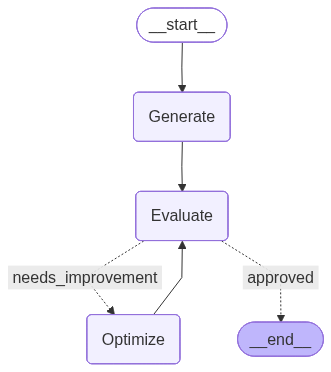

In [19]:
workflow

In [23]:
initial_state = {"topic": "Vijay Thalapathy", "max_iteration": 5, "iteration": 1}
print(workflow.invoke(initial_state))

{'topic': 'Vijay Thalapathy', 'tweet': '"Vijay Thalapathy: the action hero who\'s been fighting for 25 years and still can\'t defeat his mom\'s cooking. #KollywoodForever #ThalapathyWinsAtLife"', 'evaluation': 'approved', 'feedback': "The tweet is well-formatted and concise, adhering to character limits and avoiding common pitfalls like Q&A or setup-punchline structures. The juxtaposition of an action hero with a domestic struggle provides a mild chuckle and could resonate well within the Kollywood fandom, offering some virality potential in that specific niche. However, the 'can't defeat mom's cooking' trope, while applied here with a specific celebrity, lacks significant originality, making the humor more predictable than genuinely fresh or laugh-out-loud funny. To elevate it, aim for a more unique angle or a sharper, less common observation about the subject.", 'iteration': 1, 'max_iteration': 5}
